In [1]:
%matplotlib widget

PSF è wv dependent. Prendo l'immagine della stella di calibrazione, prendo il profilo radiale in prossimità dell'Hbeta e della'Halpha (inizio e circa fine dello spettro) e confronto le FWHM delle PSF.

In [2]:
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
from astropy.modeling import models
from scipy.signal import convolve
from scipy.optimize import minimize
from astropy.convolution import Gaussian1DKernel
import scipy.integrate as integrate
from scipy.optimize import differential_evolution
import pandas as pd
from scipy import stats

In [3]:
hdul = fits.open("mapped_flux_std_mos.fits")
hdul.info()
image = hdul[0].data

Filename: mapped_flux_std_mos.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     386   (2094, 964)   float32   
  1  IMAGE.ERR     1 ImageHDU        22   (2094, 964)   float32   


In [4]:
image_cut = image[0:200, 0:1890]

Text(0.5, 0, 'wavelength')

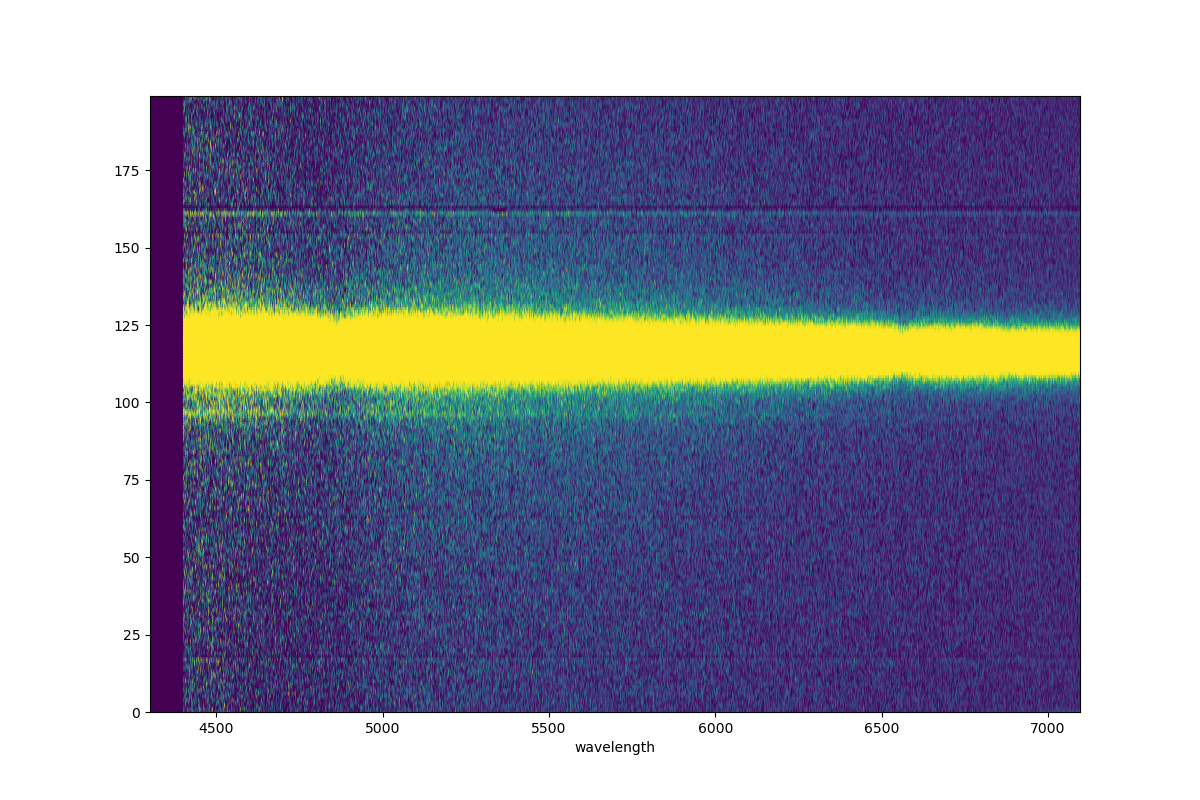

In [5]:
wv = np.arange(4300.74, 4300.74+1890*1.48, 1.48)
J, N = image_cut.data.shape
#x = np.arange(0, N, 1)
y = np.arange(0, J, 1)
arcsec_y = np.arange(-58*0.256, 42*0.256, 0.256)

x_grid, y_grid = np.meshgrid(wv, y)
plt.figure(figsize=(12,8))
plt.pcolormesh(x_grid, y_grid, image_cut, shading='gouraud', vmin=np.percentile(image_cut, 15), vmax=np.percentile(image_cut, 90))
plt.xlabel('wavelength')

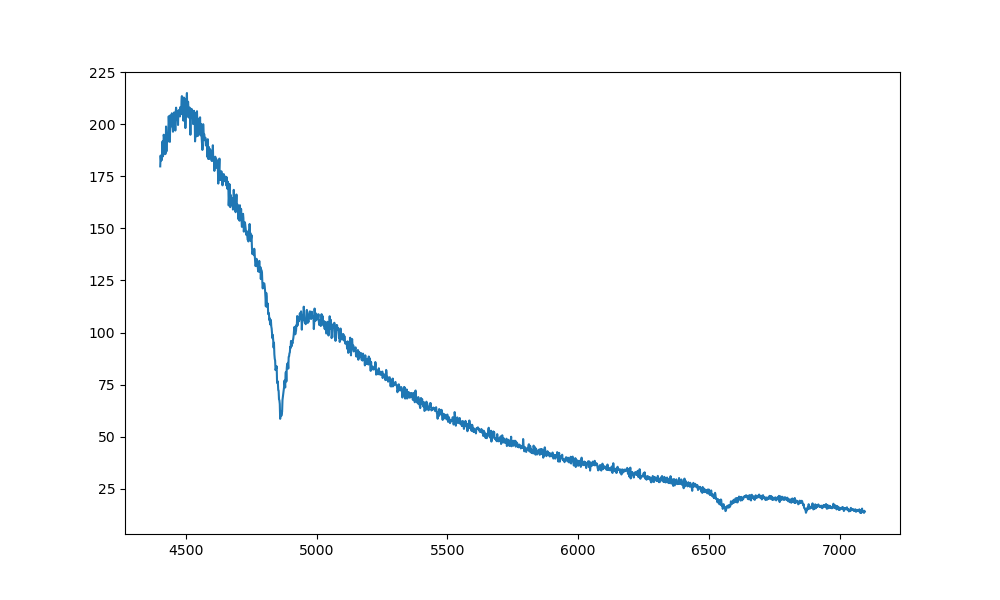

In [6]:
x_axes = np.arange(0, 200, 1)
mask = (x_axes > 119)*(x_axes < 125)
mask_wv = wv > 4400
spectrum = np.sum(image_cut[np.ix_(mask, mask_wv)], axis = 0)
plt.figure(figsize=(10, 6))
plt.plot(wv[mask_wv], spectrum)

In [7]:
len(wv[mask_wv])
wv[mask_wv][0]

4401.37999999997

In [8]:
def gaussian(x, amplitude, mean, std_dev):
    return amplitude * np.exp(-((x - mean) ** 2) / (2 * std_dev ** 2))

def estimate_gaussian_params(x, y):
    """Estimate initial parameters for Gaussian fitting"""
    amplitude_guess = np.max(y)
    mean_guess = x[np.argmax(y)]
    half_max = amplitude_guess / 2
    indices = np.where(y >= half_max)[0]
    if len(indices) > 1:
        fwhm_estimate = x[indices[-1]] - x[indices[0]]
        std_dev_guess = fwhm_estimate / 2.355
    else:
        std_dev_guess = (x[-1] - x[0]) / 6
    return [amplitude_guess, mean_guess, std_dev_guess]
      
bounds = ([0, -np.inf, 0], [np.inf, np.inf, np.inf]) 
FWHM = np.zeros(len(range(0, len(wv[mask_wv]), 10))) 
FWHM_err = np.zeros(len(range(0, len(wv[mask_wv]), 10))) 
for i in range(0, len(wv[mask_wv]), 10):
    mask = (wv > wv[mask_wv][i]) * (wv < wv[mask_wv][i] + 10)
    image = image_cut[:, mask]
    radial_profile = np.sum(image, axis = 1)
    p0 = estimate_gaussian_params(x_axes, radial_profile)
    params_curve, covariance = curve_fit(gaussian, x_axes, radial_profile, p0 = p0, bounds = bounds)
    A, mu, sigma = params_curve
    FWHM[i//10] = sigma * 2.35
    FWHM_err[i//10] = np.diag(covariance)[2]

Text(0, 0.5, 'FWHM')

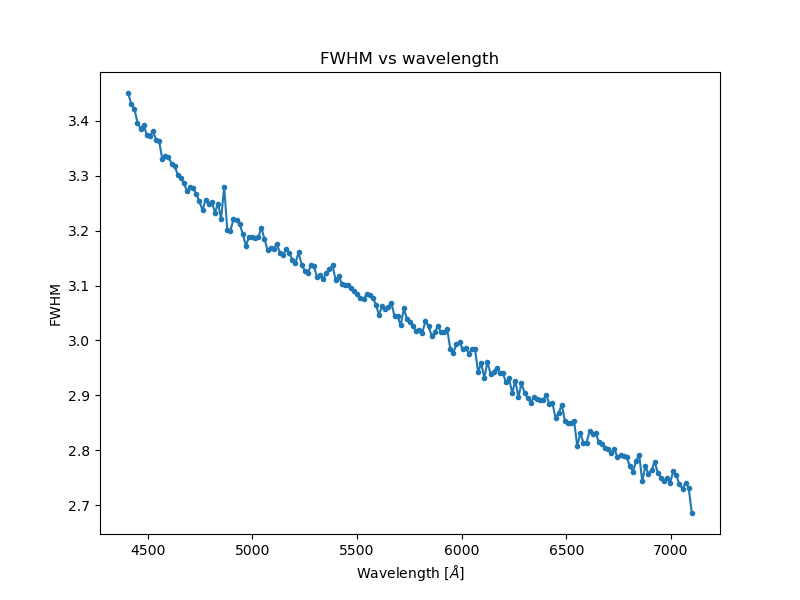

In [9]:
wv_fwhm = []
for i in range(0, len(wv[mask_wv]), 10):
    # Wavelength centrale dell'intervallo
    central_wv = wv[mask_wv][i] + 5  # Centro dell'intervallo di 10 nm
    wv_fwhm.append(central_wv)

wv_fwhm = np.array(wv_fwhm)
plt.figure(figsize=(8,6))
plt.plot(wv_fwhm, FWHM, marker='.')
plt.title('FWHM vs wavelength')
plt.xlabel(r'Wavelength [$\AA$]')
plt.ylabel('FWHM')

In [10]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel,WhiteKernel

C:\Users\ISAFA\anaconda3\Lib\site-packages\sklearn\gaussian_process\kernels.py:430: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\ISAFA\AppData\Local\Temp\ipykernel_1912\525121693.py:22: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k-" (-> color='k'). The keyword argument will take precedence.
  ax2.plot(xgrid, y_pred, 'k-', label='Fit', lw=2, color = 'deeppink')


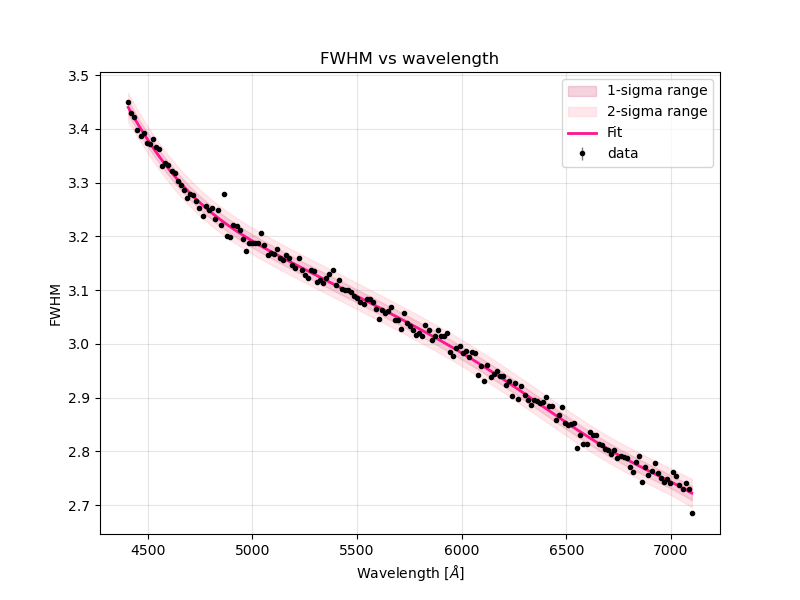

In [11]:
wv_fwhm_sample = wv_fwhm[:, np.newaxis]
FWHM_sample = FWHM[:, np.newaxis]
xgrid = np.linspace(np.min(wv_fwhm), np.max(wv_fwhm), 10000)
xpoint=xgrid[:, np.newaxis]

kernel = ConstantKernel(1.0, (1e-3, 1e3)) * RBF(length_scale=50.0,
                                                length_scale_bounds=(1.0, 1e3)) \
         + WhiteKernel(noise_level=1.0, noise_level_bounds=(1e-5, 1e1))
gp = GaussianProcessRegressor(kernel = kernel, alpha = FWHM_err**2) #length_scale: how rapidly the correlation bt points decreases with increase of the distance bt them
gp.fit(wv_fwhm_sample, FWHM_sample)
y_pred, dy_pred = gp.predict(xpoint, return_std=True)

fig2 = plt.figure(figsize=(8,6))
ax2 = fig2.gca()
ax2.grid(c='grey', alpha = 0.2)
ax2.set_title('FWHM vs wavelength')
ax2.set_xlabel(r'Wavelength [$\AA$]')
ax2.errorbar(wv_fwhm, FWHM, FWHM_err, fmt='.k', ecolor='gray', lw=1, label='data')
ax2.fill_between(xgrid, y_pred - dy_pred, y_pred + dy_pred, color='palevioletred', alpha=0.3, label='1-sigma range')
ax2.fill_between(xgrid, y_pred - 2*dy_pred, y_pred + 2*dy_pred, color='lightpink', alpha=0.3, label='2-sigma range')
ax2.set_ylabel('FWHM')
ax2.plot(xgrid, y_pred, 'k-', label='Fit', lw=2, color = 'deeppink')
ax2.legend()

In [12]:
z = 0.03401
l_HA = 6563 * (1+z)
l_HB = 4861 * (1+z) 
l_NII = 6583 * (1+z)
l_SII = 6717 * (1+z)
l_OIII = 5007 * (1+z)

lambda_list = np.array([l_HA, l_HB, l_NII, l_SII, l_OIII, 6550])        
Xq = lambda_list[:, None]                                

fwhm_pred, fwhm_sigma = gp.predict(Xq, return_std=True)

for lam, y, dy in zip(lambda_list, fwhm_pred, fwhm_sigma):
    print(f"{lam:6.0f} Å : {y:8.4f} ± {dy:7.4f}")

seeing = 3.174
real_seeing = np.zeros(5)
for i in range(len(lambda_list)-1):
    real_seeing[i] = seeing*fwhm_pred[i]/fwhm_pred[-1]
print(real_seeing)
np.savetxt('Real_seeing_UGC3141.txt', real_seeing)

  6786 Å :   2.7856 ±  0.0122
  5026 Å :   3.1854 ±  0.0122
  6807 Å :   2.7813 ±  0.0122
  6945 Å :   2.7540 ±  0.0123
  5177 Å :   3.1533 ±  0.0122
  6550 Å :   2.8408 ±  0.0122
[3.11227359 3.55894602 3.10748379 3.07703656 3.52313226]


In [13]:
l_OIII

5177.2880700000005